In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def normalize(arr):
    # min-max: result is always in [0, 1]
    min_val = arr.min()
    max_val = arr.max()
    normalized_arr = (arr - min_val) / (max_val - min_val)
    return normalized_arr, min_val, max_val

def denormalize(normalized_arr, min_val, max_val):
    # reverse: x = x_norm * (max - min) + min
    original_arr = normalized_arr * (max_val - min_val) + min_val
    return original_arr

In [3]:
np.random.seed(42)

years_experience = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10], dtype=float)
salary = np.array([35000, 42000, 50000, 58000, 65000,
                   73000, 80000, 89000, 95000, 102000], dtype=float)

print("Orijinal yıl değerleri:", years_experience)
print("Orijinal maaş değerleri:", salary)
print()

years_normalized, years_min, years_max = normalize(years_experience)
salary_normalized, salary_min, salary_max = normalize(salary)

print("Normalize edilmiş yıllar:", years_normalized.round(3))
print("Normalize edilmiş maaşlar:", salary_normalized.round(3))
print("\nArtık hepsi 0-1 arasında!")

Orijinal yıl değerleri: [ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10.]
Orijinal maaş değerleri: [ 35000.  42000.  50000.  58000.  65000.  73000.  80000.  89000.  95000.
 102000.]

Normalize edilmiş yıllar: [0.    0.111 0.222 0.333 0.444 0.556 0.667 0.778 0.889 1.   ]
Normalize edilmiş maaşlar: [0.    0.104 0.224 0.343 0.448 0.567 0.672 0.806 0.896 1.   ]

Artık hepsi 0-1 arasında!


In [4]:
class LinearRegressionAdvanced:

    def __init__(self, initial_lr=0.01, num_iterations=1000, strategy='constant',
                 decay_rate=0.001,
                 step_size=100, drop_rate=0.5,
                 restart_interval=200):

        self.initial_lr = initial_lr
        self.num_iterations = num_iterations
        self.strategy = strategy  # 'constant' | 'exponential' | 'step' | 'cosine_restart'

        self.decay_rate = decay_rate
        self.step_size = step_size
        self.drop_rate = drop_rate          # 0.5 → lr halves at each step boundary
        self.restart_interval = restart_interval

        self.w = 0.0
        self.b = 0.0

    def compute_lr(self, current_step):

        if self.strategy == 'constant':
            return self.initial_lr

        elif self.strategy == 'exponential':
            # lr = lr_0 * e^(-k * t) — decays smoothly toward zero
            current_lr = self.initial_lr * np.exp(-self.decay_rate * current_step)
            return current_lr

        elif self.strategy == 'step':
            # drops by drop_rate every step_size iterations
            steps_taken = np.floor(current_step / self.step_size)
            current_lr = self.initial_lr * (self.drop_rate ** steps_taken)
            return current_lr

        elif self.strategy == 'cosine_restart':
            # lr follows a cosine curve then restarts — helps escape local minima
            t_mod = current_step % self.restart_interval
            current_lr = self.initial_lr * 0.5 * (1 + np.cos(np.pi * t_mod / self.restart_interval))
            return current_lr

    def forward(self, x):
        y_hat = self.w * x + self.b
        return y_hat

    def compute_gradients(self, x, y, y_hat):
        n = len(y)
        # dL/dw and dL/db — MSE gradients
        dw = (-2 / n) * np.sum(x * (y - y_hat))
        db = (-2 / n) * np.sum(y - y_hat)
        return dw, db

    def update_weights(self, dw, db, current_lr):
        self.w = self.w - current_lr * dw
        self.b = self.b - current_lr * db

    def train(self, x, y):
        loss_history = []
        lr_history = []

        for i in range(self.num_iterations):
            current_lr = self.compute_lr(i)
            lr_history.append(current_lr)

            y_hat = self.forward(x)
            loss = np.mean((y - y_hat) ** 2)
            loss_history.append(loss)

            dw, db = self.compute_gradients(x, y, y_hat)
            self.update_weights(dw, db, current_lr)

        return loss_history, lr_history

In [5]:
np.random.seed(42)
x_raw = np.linspace(0, 10, 50)
y_raw = 2 * x_raw + 1 + np.random.randn(50)

x_normalized, x_min, x_max = normalize(x_raw)
y_normalized, y_min, y_max = normalize(y_raw)

print("Normalized x range:", x_normalized.min().round(3), "—", x_normalized.max().round(3))
print("Normalized y range:", y_normalized.min().round(3), "—", y_normalized.max().round(3))

Normalized x range: 0.0 — 1.0
Normalized y range: 0.0 — 1.0


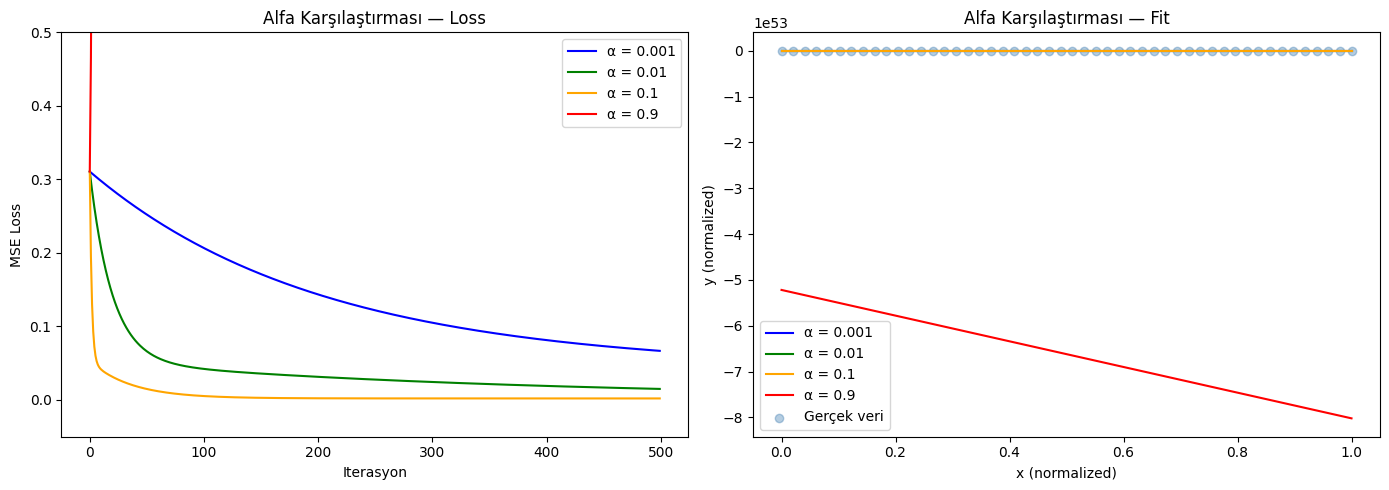


Sonuç:
α = 0.001 → çok yavaş öğrenir, loss hâlâ yüksek
α = 0.01  → dengeli, genellikle iyi seçim
α = 0.1   → hızlı ama biraz titrer
α = 0.9   → çok büyük, model büyük ihtimalle sallanır (diverge)


In [6]:
alpha_values = [0.001, 0.01, 0.1, 0.9]
colors = ['blue', 'green', 'orange', 'red']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for alpha_val, color in zip(alpha_values, colors):
    model = LinearRegressionAdvanced(
        initial_lr=alpha_val,
        num_iterations=500,
        strategy='constant'
    )
    loss_history, _ = model.train(x_normalized, y_normalized)

    axes[0].plot(loss_history, color=color, label=f'α = {alpha_val}')
    y_pred = model.forward(x_normalized)
    axes[1].plot(x_normalized, y_pred, color=color, label=f'α = {alpha_val}', linewidth=1.5)

axes[0].set_title('Alfa Karşılaştırması — Loss')
axes[0].set_xlabel('Iterasyon')
axes[0].set_ylabel('MSE Loss')
axes[0].set_ylim(-0.05, 0.5)  # clip large values so the chart stays readable
axes[0].legend()

axes[1].scatter(x_normalized, y_normalized, color='steelblue', alpha=0.4, label='Gerçek veri')
axes[1].set_title('Alfa Karşılaştırması — Fit')
axes[1].set_xlabel('x (normalized)')
axes[1].set_ylabel('y (normalized)')
axes[1].legend()

plt.tight_layout()
plt.show()

print("\nSonuç:")
print("α = 0.001 → çok yavaş öğrenir, loss hâlâ yüksek")
print("α = 0.01  → dengeli, genellikle iyi seçim")
print("α = 0.1   → hızlı ama biraz titrer")
print("α = 0.9   → çok büyük, model büyük ihtimalle sallanır (diverge)")

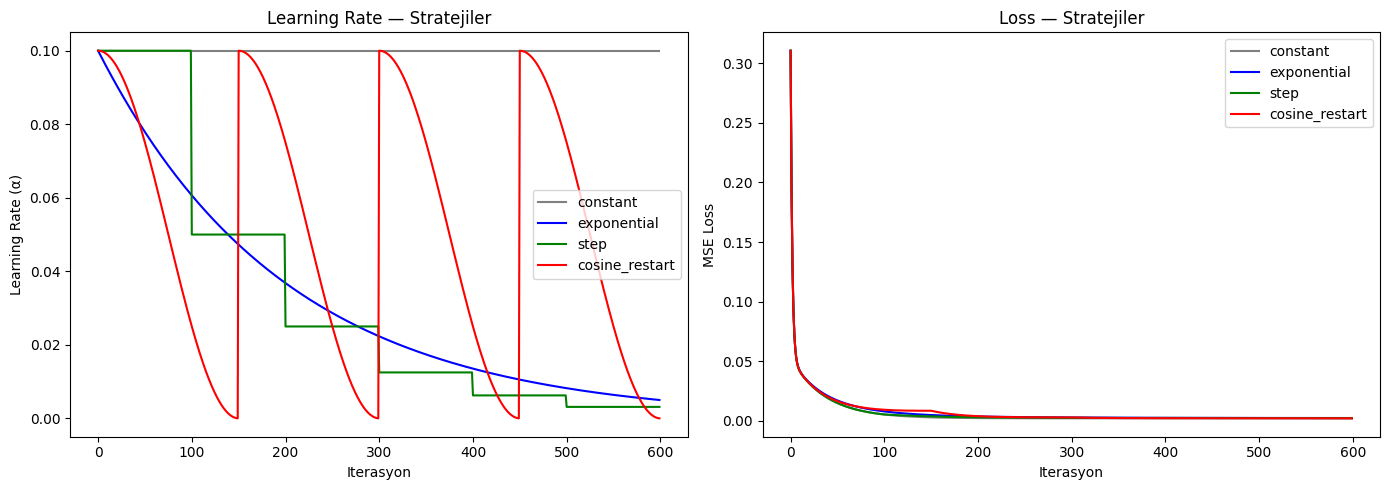

In [7]:
strategy_list = ['constant', 'exponential', 'step', 'cosine_restart']
colors = ['gray', 'blue', 'green', 'red']

fig, (ax_lr, ax_loss) = plt.subplots(1, 2, figsize=(14, 5))

for strategy_name, color in zip(strategy_list, colors):
    model = LinearRegressionAdvanced(
        initial_lr=0.1,
        num_iterations=600,
        strategy=strategy_name,
        decay_rate=0.005,
        step_size=100,
        drop_rate=0.5,
        restart_interval=150
    )
    loss_history, lr_history = model.train(x_normalized, y_normalized)

    ax_lr.plot(lr_history, color=color, label=strategy_name)
    ax_loss.plot(loss_history, color=color, label=strategy_name)

ax_lr.set_title('Learning Rate — Stratejiler')
ax_lr.set_xlabel('Iterasyon')
ax_lr.set_ylabel('Learning Rate (α)')
ax_lr.legend()

ax_loss.set_title('Loss — Stratejiler')
ax_loss.set_xlabel('Iterasyon')
ax_loss.set_ylabel('MSE Loss')
ax_loss.legend()

plt.tight_layout()
plt.show()

In [8]:
print("=== Normalizasyon Olmadan ===")
model_raw = LinearRegressionAdvanced(initial_lr=0.0000001, num_iterations=1000, strategy='constant')
loss_raw, _ = model_raw.train(years_experience, salary)
print(f"Final loss (ham veri): {loss_raw[-1]:.2f}")
print(f"Öğrenilen w: {model_raw.w:.4f}")
print()

print("=== Normalizasyon İle ===")
model_norm = LinearRegressionAdvanced(initial_lr=0.1, num_iterations=1000, strategy='constant')
loss_norm, _ = model_norm.train(years_normalized, salary_normalized)
print(f"Final loss (normalized): {loss_norm[-1]:.6f}")
print(f"Öğrenilen w: {model_norm.w:.4f}")

# predict salary for 7 years of experience
new_year = np.array([7.0])
all_years_with_new, _, _ = normalize(np.append(years_experience, new_year))
new_year_norm_val = all_years_with_new[-1:]  # grab only the new point

pred_normalized = model_norm.forward(new_year_norm_val)
pred_salary = denormalize(pred_normalized, salary_min, salary_max)

print(f"\n7 yıl deneyim için maaş tahmini: {pred_salary[0]:,.0f} TL")
print(f"(Gerçek değer veriden: {salary[6]:,.0f} TL — yakın mı?)")

=== Normalizasyon Olmadan ===
Final loss (ham veri): 5136674737.25
Öğrenilen w: 87.8740

=== Normalizasyon İle ===
Final loss (normalized): 0.000065
Öğrenilen w: 1.0119

7 yıl deneyim için maaş tahmini: 80,200 TL
(Gerçek değer veriden: 80,000 TL — yakın mı?)


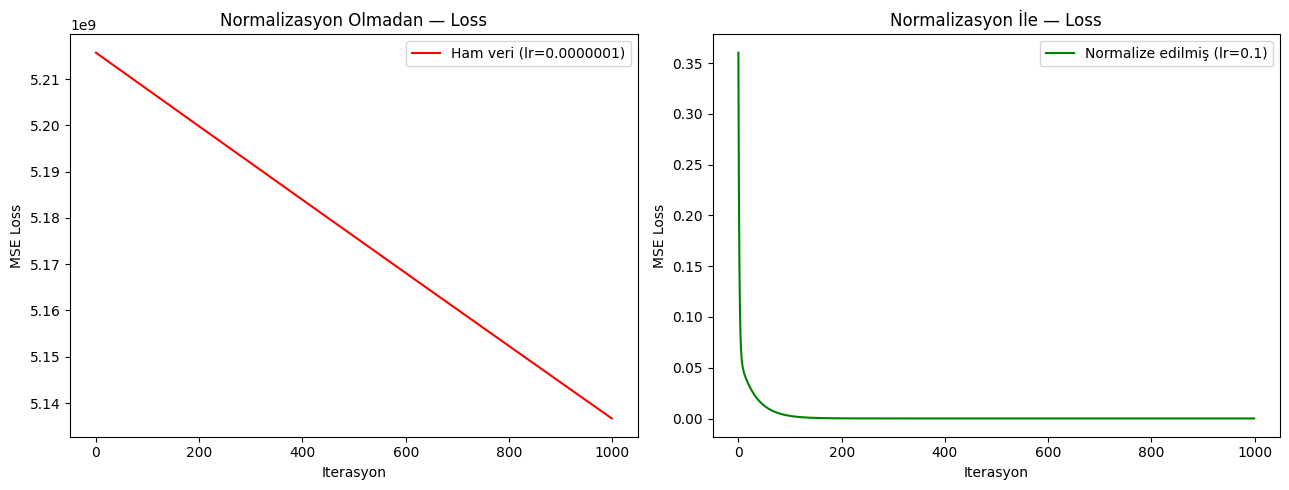

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.plot(loss_raw, color='red', label='Ham veri (lr=0.0000001)')
ax1.set_title('Normalizasyon Olmadan — Loss')
ax1.set_xlabel('Iterasyon')
ax1.set_ylabel('MSE Loss')
ax1.legend()

ax2.plot(loss_norm, color='green', label='Normalize edilmiş (lr=0.1)')
ax2.set_title('Normalizasyon İle — Loss')
ax2.set_xlabel('Iterasyon')
ax2.set_ylabel('MSE Loss')
ax2.legend()

plt.tight_layout()
plt.show()
